# 🚀 Système d'Analyse de Prix Amazon - Version Améliorée

## Améliorations clés:
- ✅ Intégration des catégories du dataset
- ✅ Distinction entre produits principaux et accessoires
- ✅ Système de scoring de pertinence
- ✅ Résultats détaillés par catégorie
- ✅ Compatible avec `final_dataset.csv`

In [14]:
import pandas as pd
import numpy as np
import warnings
import unicodedata
import re
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Optional
from dataclasses import dataclass

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Librairies chargées avec succès.")

✅ Librairies chargées avec succès.


## 📦 Classe PricePoint Améliorée

Utilise `@dataclass` pour plus de clarté et ajoute des attributs enrichis

In [15]:
@dataclass
class PricePoint:
    """
    DTO représentant un produit Amazon avec métadonnées enrichies.
    
    Attributes:
        name: Titre du produit
        price: Prix en USD
        url: Lien Amazon
        category: Catégorie du produit (ex: 'Electronics - Audio')
        rating: Note moyenne (1-5)
        reviews_count: Nombre d'avis
        is_prime: Eligible Prime ou non
        product_type: 'main_product' ou 'accessory' (calculé automatiquement)
    """
    name: str
    price: float
    url: str
    category: str = "Other"
    rating: float = 0.0
    reviews_count: int = 0
    is_prime: bool = False
    product_type: str = "main_product"  # ou "accessory"
    
    def __post_init__(self):
        """Détermine automatiquement si c'est un accessoire"""
        self.product_type = self._detect_product_type()
    
    def _detect_product_type(self) -> str:
        """Détecte si le produit est un accessoire basé sur des mots-clés"""
        accessory_keywords = [
            'case', 'cover', 'sleeve', 'bag', 'backpack', 'pouch',
            'charger', 'cable', 'adapter', 'cord', 'power bank',
            'screen protector', 'stand', 'holder', 'mount',
            'strap', 'band', 'skin', 'sticker', 'decal'
        ]
        
        name_lower = self.name.lower()
        
        # Un produit est un accessoire s'il commence par un mot-clé accessoire
        # ou si le mot-clé apparaît dans les 5 premiers mots
        first_words = ' '.join(name_lower.split()[:5])
        
        for keyword in accessory_keywords:
            if keyword in first_words:
                return "accessory"
        
        return "main_product"
    
    def __repr__(self):
        type_emoji = "🔧" if self.product_type == "accessory" else "📦"
        return f"{type_emoji} [{self.category}] {self.name[:50]}... : ${self.price:.2f} ({self.rating}⭐)"

print("✅ Classe PricePoint améliorée définie.")

✅ Classe PricePoint améliorée définie.


## 🔄 Chargement des Données

In [16]:
def load_amazon_data(csv_path: str = "final_dataset.csv") -> List[PricePoint]:
    """
    Charge le dataset Amazon et crée des objets PricePoint enrichis.
    
    Args:
        csv_path: Chemin vers le fichier CSV
        
    Returns:
        Liste d'objets PricePoint
    """
    print(f"🔄 Chargement de la base : {csv_path}...")
    
    try:
        df = pd.read_csv(csv_path, on_bad_lines='skip')
        print(f"   📊 {len(df):,} lignes chargées")
    except Exception as e:
        print(f"❌ Erreur critique lors de la lecture du fichier : {e}")
        return []
    
    clean_objects = []
    
    for index, row in df.iterrows():
        try:
            # Extraction des données
            title = str(row.get('title', 'Unknown'))
            price = row.get('price', 0)
            url = str(row.get('url', ''))
            category = str(row.get('category', 'Other'))
            rating = float(row.get('rating', 0))
            reviews = int(row.get('reviews_count', 0))
            is_prime = bool(row.get('isPrime', False))
            
            # Nettoyage du prix
            if pd.isna(price) or price == 0:
                continue
                
            # Création de l'objet
            product = PricePoint(
                name=title,
                price=float(price),
                url=url,
                category=category,
                rating=rating,
                reviews_count=reviews,
                is_prime=is_prime
            )
            
            clean_objects.append(product)
            
        except Exception as e:
            continue
    
    # Statistiques de chargement
    main_products = sum(1 for p in clean_objects if p.product_type == "main_product")
    accessories = sum(1 for p in clean_objects if p.product_type == "accessory")
    
    print(f"\n✅ Chargement terminé :")
    print(f"   📦 {main_products:,} produits principaux")
    print(f"   🔧 {accessories:,} accessoires")
    print(f"   🎯 Total: {len(clean_objects):,} produits valides")
    
    return clean_objects

print("✅ Fonction load_amazon_data() définie.")

✅ Fonction load_amazon_data() définie.


## 🧠 MarketAnalyzer Amélioré

### Nouvelles fonctionnalités:
- Filtrage par type de produit (principal/accessoire)
- Scoring de pertinence
- Résultats détaillés par catégorie
- Statistiques enrichies

In [17]:
class MarketAnalyzer:
    """
    Analyseur de marché Amazon intelligent.
    
    Permet de:
    - Estimer les prix de produits
    - Filtrer par type (produit principal vs accessoire)
    - Analyser par catégorie
    - Scorer la pertinence des résultats
    """
    
    def __init__(self, all_products: List[PricePoint]):
        self.database = all_products
        
        # Dictionnaire de synonymes étendu
        self.category_synonyms = {
            # Informatique
            "laptop": ["computer", "notebook", "pc", "chromebook", "ultrabook", "macbook"],
            "pc": ["laptop", "computer", "desktop"],
            "ordinateur": ["laptop", "pc", "computer"],
            "screen": ["monitor", "display", "lcd"],
            
            # Mobile / Tablette
            "phone": ["smartphone", "cellphone", "mobile", "android", "iphone"],
            "smartphone": ["phone", "cellphone", "mobile"],
            "tablette": ["tablet", "ipad", "tab"],
            
            # Wearables
            "watch": ["smartwatch", "tracker", "gps", "wearable", "fitness"],
            "montre": ["watch", "smartwatch", "gps"],
            
            # Audio
            "headphones": ["earbuds", "earphones", "headset", "bluetooth", "airpods"],
            "ecouteur": ["earbuds", "headphones", "earphones"],
            
            # Accessoires
            "case": ["cover", "sleeve", "protection", "shell"],
            "sac": ["bag", "backpack", "case", "sleeve"],
            "chargeur": ["charger", "adapter", "cable", "cord", "power"],
            "souris": ["mouse"],
        }
    
    def _normalize(self, text: str) -> str:
        """Normalise le texte (enlève accents, met en minuscule)"""
        if not isinstance(text, str):
            return ""
        text = unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8")
        return text.lower().strip()
    
    def _expand_query(self, user_query: str) -> List[str]:
        """Transforme une requête utilisateur en critères de recherche"""
        words = self._normalize(user_query).split()
        expanded_criteria = []
        
        for word in words:
            if word in self.category_synonyms:
                options = [word] + self.category_synonyms[word]
                expanded_criteria.append("|".join(options))
            else:
                expanded_criteria.append(word)
        
        return expanded_criteria
    
    def _calculate_relevance_score(self, product: PricePoint, criteria_list: List[str]) -> float:
        """
        Calcule un score de pertinence pour un produit.
        Plus le match est au début du titre, plus le score est élevé.
        """
        name_norm = self._normalize(product.name)
        score = 0.0
        
        for criteria in criteria_list:
            if '|' in criteria:
                options = criteria.split('|')
                for opt in options:
                    pos = name_norm.find(opt)
                    if pos != -1:
                        # Score inversement proportionnel à la position
                        score += 100 / (pos + 1)
                        break
            else:
                pos = name_norm.find(criteria)
                if pos != -1:
                    score += 100 / (pos + 1)
        
        return score
    
    def _match_product(self, product: PricePoint, criteria_list: List[str]) -> bool:
        """Vérifie si un produit correspond aux critères de recherche"""
        name_norm = self._normalize(product.name)
        
        for criteria in criteria_list:
            if '|' in criteria:  # Concept (OR)
                options = criteria.split('|')
                if not any(opt in name_norm for opt in options):
                    return False
            else:  # Marque/modèle (AND)
                if criteria not in name_norm:
                    return False
        
        return True
    
    def get_price_estimate(
        self, 
        user_input: str, 
        product_type: Optional[str] = None,
        min_samples: int = 3,
        iqr_factor: float = 2.0
    ) -> Dict:
        """
        Estime le prix d'un produit basé sur la requête utilisateur.
        
        Args:
            user_input: Requête (ex: "Lenovo Laptop", "Chargeur iPhone")
            product_type: Filtrer par type:
                - None: tous les produits
                - "main_product": uniquement produits principaux
                - "accessory": uniquement accessoires
            min_samples: Nombre minimum de produits pour une estimation
            iqr_factor: Facteur pour le filtrage IQR (plus élevé = plus permissif)
        
        Returns:
            Dictionnaire avec les résultats d'analyse
        """
        # 1. Analyse de la requête
        criteria_list = self._expand_query(user_input)
        print(f"\n🧠 Requête: '{user_input}'")
        print(f"   Critères: {criteria_list}")
        if product_type:
            type_label = "🔧 Accessoires" if product_type == "accessory" else "📦 Produits principaux"
            print(f"   Filtre: {type_label}")
        
        # 2. Matching et scoring
        matches = []
        for product in self.database:
            # Filtrer par type si spécifié
            if product_type and product.product_type != product_type:
                continue
            
            # Vérifier le match
            if self._match_product(product, criteria_list):
                relevance_score = self._calculate_relevance_score(product, criteria_list)
                matches.append((product, relevance_score))
        
        # Trier par pertinence
        matches.sort(key=lambda x: x[1], reverse=True)
        
        # 3. Vérification du nombre de résultats
        if len(matches) < min_samples:
            return {
                "success": False,
                "message": f"Pas assez de produits trouvés ({len(matches)}/{min_samples} requis).",
                "matches_count": len(matches)
            }
        
        # 4. Analyse statistique avec IQR
        prices = [p.price for p, _ in matches]
        q1 = np.percentile(prices, 25)
        q3 = np.percentile(prices, 75)
        iqr = q3 - q1
        
        # Filtrage des outliers (plus permissif avec iqr_factor=2.0)
        clean_matches = [
            (p, s) for p, s in matches 
            if (q1 - iqr_factor*iqr) <= p.price <= (q3 + iqr_factor*iqr)
        ]
        
        if not clean_matches:
            clean_matches = matches  # Fallback
        
        clean_prices = [p.price for p, _ in clean_matches]
        
        # 5. Analyse par catégorie
        category_breakdown = {}
        for product, score in clean_matches:
            cat = product.category
            if cat not in category_breakdown:
                category_breakdown[cat] = []
            category_breakdown[cat].append(product.price)
        
        category_stats = {
            cat: {
                "count": len(prices),
                "median": np.median(prices),
                "mean": np.mean(prices)
            }
            for cat, prices in category_breakdown.items()
        }
        
        # 6. Top résultats
        top_matches = clean_matches[:10]
        
        return {
            "success": True,
            "query": user_input,
            "product_type_filter": product_type,
            "total_matches": len(matches),
            "clean_matches": len(clean_matches),
            "fair_price": round(np.median(clean_prices), 2),
            "mean_price": round(np.mean(clean_prices), 2),
            "min_price": round(np.min(clean_prices), 2),
            "max_price": round(np.max(clean_prices), 2),
            "std_dev": round(np.std(clean_prices), 2),
            "categories": category_stats,
            "top_products": top_matches
        }
    
    def display_results(self, result: Dict):
        """Affiche joliment les résultats d'une estimation"""
        if not result["success"]:
            print(f"\n⚠️  {result['message']}")
            return
        
        print(f"\n" + "="*70)
        print(f"📊 RÉSULTATS POUR: {result['query']}")
        print("="*70)
        
        print(f"\n💰 ESTIMATION DE PRIX:")
        print(f"   Prix Recommandé (médian): ${result['fair_price']:.2f}")
        print(f"   Prix Moyen:               ${result['mean_price']:.2f}")
        print(f"   Fourchette:               ${result['min_price']:.2f} - ${result['max_price']:.2f}")
        print(f"   Écart-type:               ${result['std_dev']:.2f}")
        
        print(f"\n📦 ÉCHANTILLON:")
        print(f"   Produits trouvés:  {result['total_matches']}")
        print(f"   Produits analysés: {result['clean_matches']} (après filtrage outliers)")
        
        if result['categories']:
            print(f"\n🏷️  RÉPARTITION PAR CATÉGORIE:")
            for cat, stats in sorted(result['categories'].items(), 
                                    key=lambda x: x[1]['count'], 
                                    reverse=True)[:5]:
                print(f"   • {cat}")
                print(f"     {stats['count']} produits | Médian: ${stats['median']:.2f}")
        
        print(f"\n🏆 TOP 5 RÉSULTATS (par pertinence):")
        for i, (product, score) in enumerate(result['top_products'][:5], 1):
            print(f"   {i}. ${product.price:.2f} | {product.rating}⭐ ({product.reviews_count:,} avis)")
            print(f"      [{product.category}]")
            print(f"      {product.name[:80]}...")
            print()
        
        print("="*70)

print("✅ Classe MarketAnalyzer améliorée définie.")

✅ Classe MarketAnalyzer améliorée définie.


## 📊 Dashboard d'Analyse Globale

In [18]:
def dashboard_analyse(analyzer: MarketAnalyzer):
    """
    Génère un dashboard complet de la base de données.
    """
    print("\n" + "="*80)
    print("📊 DASHBOARD AMAZON - VUE D'ENSEMBLE")
    print("="*80)
    
    # Conversion en DataFrame
    data = [
        {
            "name": p.name,
            "price": p.price,
            "category": p.category,
            "rating": p.rating,
            "reviews": p.reviews_count,
            "type": p.product_type,
            "is_prime": p.is_prime
        }
        for p in analyzer.database
    ]
    df = pd.DataFrame(data)
    
    # Statistiques globales
    print(f"\n📦 STATISTIQUES GLOBALES:")
    print(f"   Total produits:        {len(df):,}")
    print(f"   Produits principaux:   {(df['type'] == 'main_product').sum():,}")
    print(f"   Accessoires:           {(df['type'] == 'accessory').sum():,}")
    print(f"   Produits Prime:        {df['is_prime'].sum():,}")
    
    # Statistiques de prix
    print(f"\n💰 PRIX:")
    print(f"   Prix moyen global:     ${df['price'].mean():.2f}")
    print(f"   Prix médian:           ${df['price'].median():.2f}")
    print(f"   Prix min/max:          ${df['price'].min():.2f} - ${df['price'].max():,.2f}")
    
    # Comparaison produits vs accessoires
    print(f"\n🔍 COMPARAISON PRODUITS vs ACCESSOIRES:")
    for ptype in ['main_product', 'accessory']:
        subset = df[df['type'] == ptype]
        label = "📦 Produits principaux" if ptype == "main_product" else "🔧 Accessoires"
        print(f"\n   {label}:")
        print(f"      Quantité:      {len(subset):,}")
        print(f"      Prix médian:   ${subset['price'].median():.2f}")
        print(f"      Note moyenne:  {subset['rating'].mean():.2f}⭐")
    
    # Top catégories
    print(f"\n🏷️  TOP 10 CATÉGORIES:")
    top_cats = df['category'].value_counts().head(10)
    for i, (cat, count) in enumerate(top_cats.items(), 1):
        pct = count / len(df) * 100
        print(f"   {i:2d}. {cat:45} : {count:6,} ({pct:5.1f}%)")
    
    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribution des prix (log scale)
    df_price = df[df['price'] > 0]
    axes[0, 0].hist(df_price['price'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Prix ($)')
    axes[0, 0].set_ylabel('Nombre de produits')
    axes[0, 0].set_title('Distribution des Prix')
    axes[0, 0].set_xlim(0, df_price['price'].quantile(0.95))
    
    # 2. Produits vs Accessoires
    type_counts = df['type'].value_counts()
    axes[0, 1].pie(type_counts.values, labels=['Produits\nPrincipaux', 'Accessoires'],
                  autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e74c3c'])
    axes[0, 1].set_title('Répartition Produits / Accessoires')
    
    # 3. Prix moyen par catégorie (Top 10)
    cat_prices = df.groupby('category')['price'].median().sort_values(ascending=False).head(10)
    axes[1, 0].barh(range(len(cat_prices)), cat_prices.values, color='skyblue')
    axes[1, 0].set_yticks(range(len(cat_prices)))
    axes[1, 0].set_yticklabels(cat_prices.index, fontsize=9)
    axes[1, 0].set_xlabel('Prix Médian ($)')
    axes[1, 0].set_title('Prix Médian par Catégorie (Top 10)')
    axes[1, 0].invert_yaxis()
    
    # 4. Notes moyennes par catégorie
    cat_ratings = df.groupby('category')['rating'].mean().sort_values(ascending=False).head(10)
    axes[1, 1].barh(range(len(cat_ratings)), cat_ratings.values, color='gold')
    axes[1, 1].set_yticks(range(len(cat_ratings)))
    axes[1, 1].set_yticklabels(cat_ratings.index, fontsize=9)
    axes[1, 1].set_xlabel('Note Moyenne (/5)')
    axes[1, 1].set_title('Note Moyenne par Catégorie (Top 10)')
    axes[1, 1].set_xlim(0, 5)
    axes[1, 1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)

print("✅ Fonction dashboard_analyse() définie.")

✅ Fonction dashboard_analyse() définie.


## 🚀 EXÉCUTION - Chargement et Analyse

In [19]:
# Chargement des données
products = load_amazon_data("final_dataset.csv")
analyzer = MarketAnalyzer(products)

🔄 Chargement de la base : final_dataset.csv...
   📊 50,444 lignes chargées

✅ Chargement terminé :
   📦 46,105 produits principaux
   🔧 3,583 accessoires
   🎯 Total: 49,688 produits valides



📊 DASHBOARD AMAZON - VUE D'ENSEMBLE

📦 STATISTIQUES GLOBALES:
   Total produits:        49,688
   Produits principaux:   46,105
   Accessoires:           3,583
   Produits Prime:        292

💰 PRIX:
   Prix moyen global:     $76.71
   Prix médian:           $24.99
   Prix min/max:          $0.00 - $399,800.00

🔍 COMPARAISON PRODUITS vs ACCESSOIRES:

   📦 Produits principaux:
      Quantité:      46,105
      Prix médian:   $24.99
      Note moyenne:  4.49⭐

   🔧 Accessoires:
      Quantité:      3,583
      Prix médian:   $23.99
      Note moyenne:  4.50⭐

🏷️  TOP 10 CATÉGORIES:
    1. Other                                         : 16,931 ( 34.1%)
    2. Clothing & Accessories                        :  4,074 (  8.2%)
    3. Home & Kitchen - Furniture                    :  3,778 (  7.6%)
    4. Beauty & Personal Care                        :  2,481 (  5.0%)
    5. Sports & Outdoors                             :  2,142 (  4.3%)
    6. Baby Products                                 :  1,

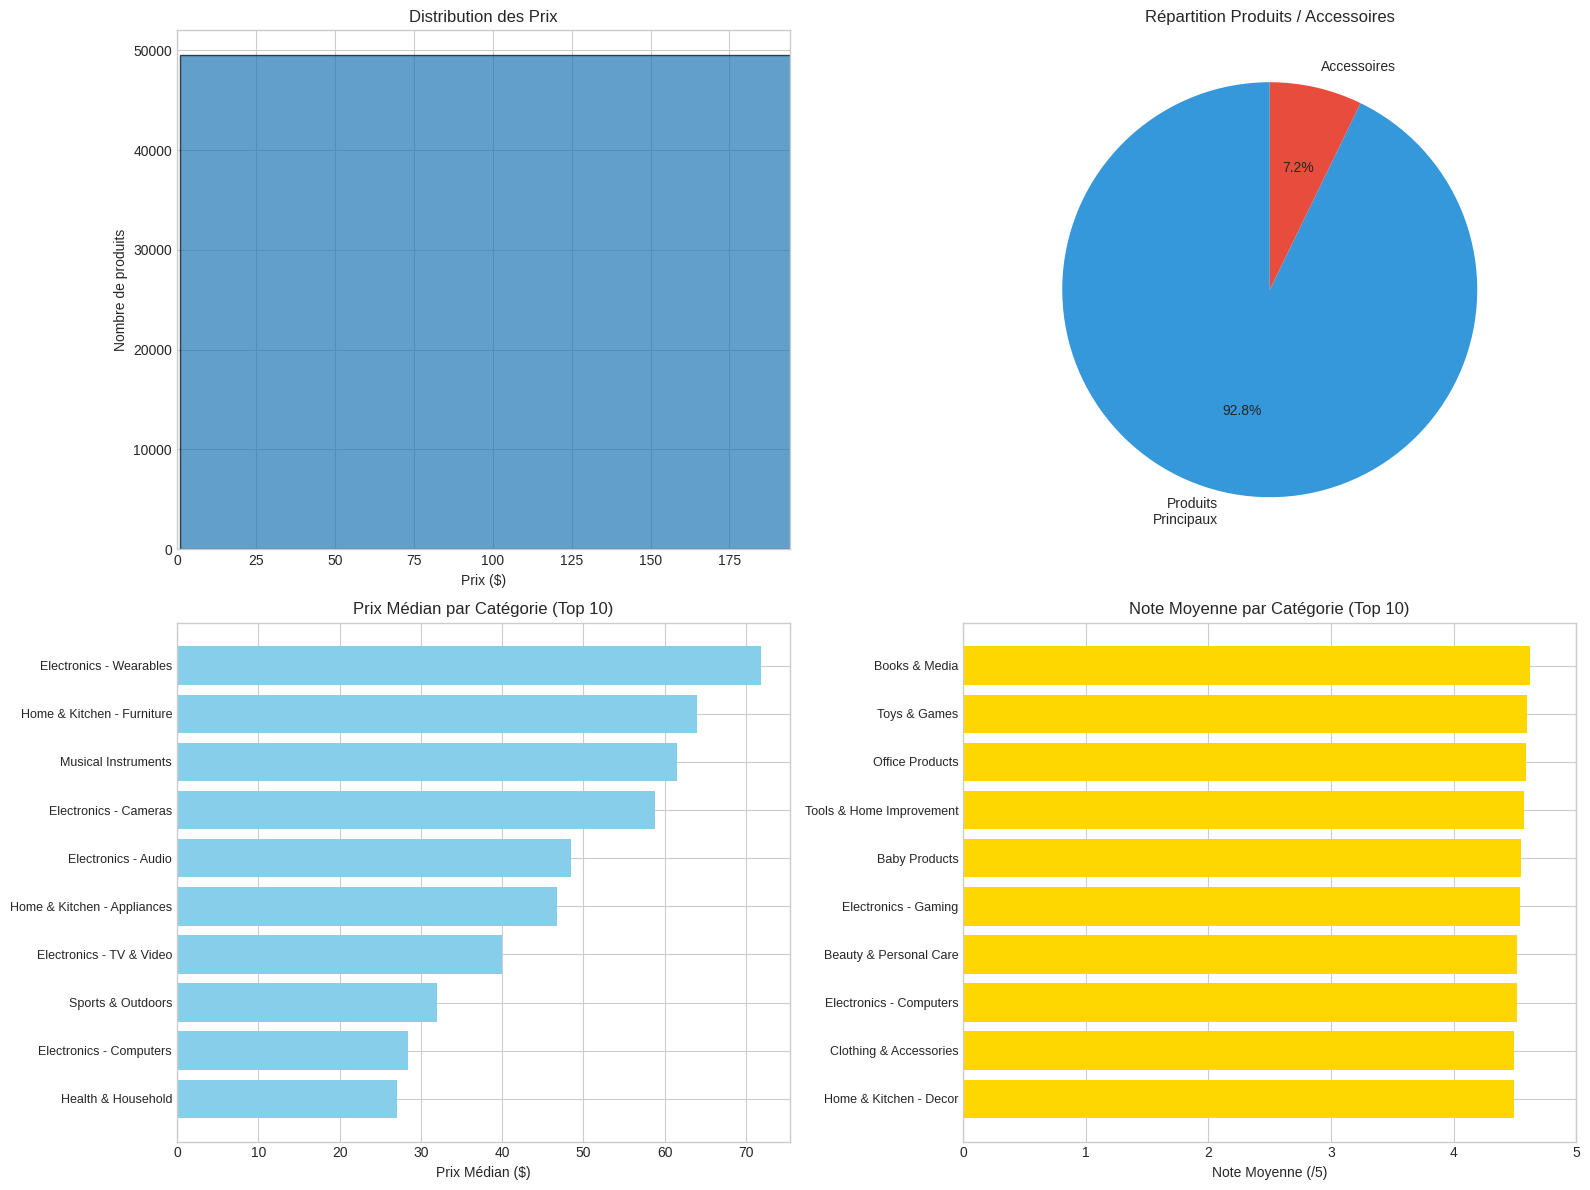

In [20]:
# Dashboard global
dashboard_analyse(analyzer)

## 🧪 TESTS - Cas d'Usage Variés

### Test 1: Recherche de produits principaux uniquement

In [21]:
# Recherche de laptops (produits principaux uniquement)
result = analyzer.get_price_estimate("Lenovo Laptop", product_type="main_product")
analyzer.display_results(result)


🧠 Requête: 'Lenovo Laptop'
   Critères: ['lenovo', 'laptop|computer|notebook|pc|chromebook|ultrabook|macbook']
   Filtre: 📦 Produits principaux

📊 RÉSULTATS POUR: Lenovo Laptop

💰 ESTIMATION DE PRIX:
   Prix Recommandé (médian): $414.99
   Prix Moyen:               $367.74
   Fourchette:               $14.99 - $769.99
   Écart-type:               $234.85

📦 ÉCHANTILLON:
   Produits trouvés:  8
   Produits analysés: 8 (après filtrage outliers)

🏷️  RÉPARTITION PAR CATÉGORIE:
   • Electronics - Computers
     7 produits | Médian: $429.99
   • Electronics - TV & Video
     1 produits | Médian: $32.99

🏆 TOP 5 RÉSULTATS (par pertinence):
   1. $299.98 | 4.3⭐ (65 avis)
      [Electronics - Computers]
      lenovo laptop computers for home business student study, 15.6" fhd, intel proces...

   2. $429.99 | 4.5⭐ (388 avis)
      [Electronics - Computers]
      lenovo 2026 new v15 laptop for student & business, powerful amd ryzen 3 7320u (b...

   3. $399.99 | 4.5⭐ (388 avis)
      [Electroni

### Test 2: Recherche d'accessoires uniquement

In [22]:
# Recherche de sacs pour laptop (accessoires uniquement)
result = analyzer.get_price_estimate("Laptop Bag", product_type="accessory")
analyzer.display_results(result)


🧠 Requête: 'Laptop Bag'
   Critères: ['laptop|computer|notebook|pc|chromebook|ultrabook|macbook', 'bag']
   Filtre: 🔧 Accessoires

📊 RÉSULTATS POUR: Laptop Bag

💰 ESTIMATION DE PRIX:
   Prix Recommandé (médian): $28.99
   Prix Moyen:               $28.96
   Fourchette:               $5.98 - $69.99
   Écart-type:               $12.80

📦 ÉCHANTILLON:
   Produits trouvés:  141
   Produits analysés: 137 (après filtrage outliers)

🏷️  RÉPARTITION PAR CATÉGORIE:
   • Clothing & Accessories
     68 produits | Médian: $30.98
   • Electronics - Computers
     54 produits | Médian: $21.19
   • Sports & Outdoors
     7 produits | Médian: $20.99
   • Baby Products
     3 produits | Médian: $33.01
   • Other
     2 produits | Médian: $37.99

🏆 TOP 5 RÉSULTATS (par pertinence):
   1. $29.99 | 4.5⭐ (75 avis)
      [Clothing & Accessories]
      bagsure 4pcs women fashion handbags purses wallet shoulder bags casual tote bag ...

   2. $9.99 | 4.8⭐ (5,536 avis)
      [Electronics - Computers]
      ba

### Test 3: Recherche sans filtre (tous types)

In [23]:
# Recherche de chargeurs Apple (produits ET accessoires)
result = analyzer.get_price_estimate("Chargeur Apple")
analyzer.display_results(result)


🧠 Requête: 'Chargeur Apple'
   Critères: ['chargeur|charger|adapter|cable|cord|power', 'apple']

📊 RÉSULTATS POUR: Chargeur Apple

💰 ESTIMATION DE PRIX:
   Prix Recommandé (médian): $9.99
   Prix Moyen:               $11.84
   Fourchette:               $3.99 - $27.99
   Écart-type:               $5.71

📦 ÉCHANTILLON:
   Produits trouvés:  46
   Produits analysés: 42 (après filtrage outliers)

🏷️  RÉPARTITION PAR CATÉGORIE:
   • Electronics - Mobile & Accessories
     32 produits | Médian: $8.99
   • Electronics - TV & Video
     3 produits | Médian: $13.99
   • Baby Products
     3 produits | Médian: $17.91
   • Other
     2 produits | Médian: $14.23
   • Electronics - Computers
     2 produits | Médian: $16.49

🏆 TOP 5 RÉSULTATS (par pertinence):
   1. $15.00 | 4.7⭐ (33,171 avis)
      [Other]
      apple lightning to usb cable (1 m) ​​​​​​​...

   2. $13.47 | 4.7⭐ (9,573 avis)
      [Other]
      apple usb-c to lightning cable (1 m): fast and convenient charging, lightning to...

  

### Test 4: Comparaison Produit vs Accessoire

In [24]:
# Comparaison: Montres Garmin
print("\n🔍 COMPARAISON: Montres Garmin (Produits) vs Accessoires Garmin")
print("="*80)

result_watches = analyzer.get_price_estimate("Garmin Watch", product_type="main_product")
result_accessories = analyzer.get_price_estimate("Garmin", product_type="accessory")

print("\n📦 PRODUITS PRINCIPAUX:")
if result_watches['success']:
    print(f"   Prix médian: ${result_watches['fair_price']:.2f}")
    print(f"   Fourchette:  ${result_watches['min_price']:.2f} - ${result_watches['max_price']:.2f}")

print("\n🔧 ACCESSOIRES:")
if result_accessories['success']:
    print(f"   Prix médian: ${result_accessories['fair_price']:.2f}")
    print(f"   Fourchette:  ${result_accessories['min_price']:.2f} - ${result_accessories['max_price']:.2f}")
else:
    print(f"   {result_accessories['message']}")


🔍 COMPARAISON: Montres Garmin (Produits) vs Accessoires Garmin

🧠 Requête: 'Garmin Watch'
   Critères: ['garmin', 'watch|smartwatch|tracker|gps|wearable|fitness']
   Filtre: 📦 Produits principaux

🧠 Requête: 'Garmin'
   Critères: ['garmin']
   Filtre: 🔧 Accessoires

📦 PRODUITS PRINCIPAUX:
   Prix médian: $167.75
   Fourchette:  $14.50 - $349.99

🔧 ACCESSOIRES:
   Pas assez de produits trouvés (1/3 requis).


### Test 5: Série de Tests Complets

In [25]:
# Batterie de tests
test_cases = [
    ("Sony Headphones", "main_product"),
    ("iPhone Case", "accessory"),
    ("Samsung Phone", "main_product"),
    ("USB Cable", "accessory"),
    ("Gaming Mouse", None),  # Tous types
]

print("\n" + "="*80)
print("🧪 BATTERIE DE TESTS")
print("="*80)

for query, ptype in test_cases:
    result = analyzer.get_price_estimate(query, product_type=ptype)
    
    if result['success']:
        print(f"\n✅ {query} ({ptype or 'tous types'})")
        print(f"   💰 Prix: ${result['fair_price']:.2f} (${result['min_price']:.2f}-${result['max_price']:.2f})")
        print(f"   📊 {result['clean_matches']} produits analysés")
    else:
        print(f"\n⚠️  {query} ({ptype or 'tous types'}): {result['message']}")


🧪 BATTERIE DE TESTS

🧠 Requête: 'Sony Headphones'
   Critères: ['sony', 'headphones|earbuds|earphones|headset|bluetooth|airpods']
   Filtre: 📦 Produits principaux

✅ Sony Headphones (main_product)
   💰 Prix: $48.00 ($14.88-$98.00)
   📊 7 produits analysés

🧠 Requête: 'iPhone Case'
   Critères: ['iphone', 'case|cover|sleeve|protection|shell']
   Filtre: 🔧 Accessoires

✅ iPhone Case (accessory)
   💰 Prix: $14.49 ($5.99-$33.98)
   📊 30 produits analysés

🧠 Requête: 'Samsung Phone'
   Critères: ['samsung', 'phone|smartphone|cellphone|mobile|android|iphone']
   Filtre: 📦 Produits principaux

✅ Samsung Phone (main_product)
   💰 Prix: $23.99 ($8.49-$66.99)
   📊 17 produits analysés

🧠 Requête: 'USB Cable'
   Critères: ['usb', 'cable']
   Filtre: 🔧 Accessoires

✅ USB Cable (accessory)
   💰 Prix: $9.99 ($5.59-$37.99)
   📊 36 produits analysés

🧠 Requête: 'Gaming Mouse'
   Critères: ['gaming', 'mouse']

✅ Gaming Mouse (tous types)
   💰 Prix: $18.99 ($2.99-$89.99)
   📊 117 produits analysés


## 📈 Analyse Avancée: Catégories les Plus Rentables

In [26]:
def analyze_profitable_categories(analyzer: MarketAnalyzer, top_n: int = 10):
    """
    Identifie les catégories les plus intéressantes pour la vente.
    Critères: Prix élevé + Bonne note + Nombre de produits significatif
    """
    data = [
        {
            "category": p.category,
            "price": p.price,
            "rating": p.rating,
            "reviews": p.reviews_count
        }
        for p in analyzer.database
    ]
    df = pd.DataFrame(data)
    
    # Agrégation par catégorie
    cat_stats = df.groupby('category').agg({
        'price': ['median', 'mean', 'count'],
        'rating': 'mean',
        'reviews': 'sum'
    }).round(2)
    
    cat_stats.columns = ['median_price', 'mean_price', 'product_count', 'avg_rating', 'total_reviews']
    
    # Filtrer: au moins 50 produits
    cat_stats = cat_stats[cat_stats['product_count'] >= 50]
    
    # Score de rentabilité: (prix médian * note moyenne) / 100
    cat_stats['profit_score'] = (cat_stats['median_price'] * cat_stats['avg_rating']) / 10
    
    # Trier par score
    cat_stats = cat_stats.sort_values('profit_score', ascending=False)
    
    print("\n" + "="*80)
    print(f"💎 TOP {top_n} CATÉGORIES LES PLUS RENTABLES")
    print("="*80)
    print("\nCritères: Prix médian élevé + Bonne note + Min 50 produits")
    print("\n")
    
    for i, (cat, row) in enumerate(cat_stats.head(top_n).iterrows(), 1):
        print(f"{i:2d}. {cat}")
        print(f"    💰 Prix médian: ${row['median_price']:.2f}")
        print(f"    ⭐ Note moyenne: {row['avg_rating']:.2f}/5")
        print(f"    📦 Produits: {int(row['product_count'])}")
        print(f"    🎯 Score rentabilité: {row['profit_score']:.1f}")
        print()

# Exécution
analyze_profitable_categories(analyzer, top_n=10)


💎 TOP 10 CATÉGORIES LES PLUS RENTABLES

Critères: Prix médian élevé + Bonne note + Min 50 produits


 1. Electronics - Wearables
    💰 Prix médian: $71.78
    ⭐ Note moyenne: 4.38/5
    📦 Produits: 81
    🎯 Score rentabilité: 31.4

 2. Home & Kitchen - Furniture
    💰 Prix médian: $63.99
    ⭐ Note moyenne: 4.43/5
    📦 Produits: 3778
    🎯 Score rentabilité: 28.3

 3. Musical Instruments
    💰 Prix médian: $61.47
    ⭐ Note moyenne: 4.42/5
    📦 Produits: 526
    🎯 Score rentabilité: 27.2

 4. Electronics - Cameras
    💰 Prix médian: $58.82
    ⭐ Note moyenne: 4.40/5
    📦 Produits: 256
    🎯 Score rentabilité: 25.9

 5. Electronics - Audio
    💰 Prix médian: $48.50
    ⭐ Note moyenne: 4.42/5
    📦 Produits: 346
    🎯 Score rentabilité: 21.4

 6. Home & Kitchen - Appliances
    💰 Prix médian: $46.72
    ⭐ Note moyenne: 4.44/5
    📦 Produits: 1508
    🎯 Score rentabilité: 20.7

 7. Electronics - TV & Video
    💰 Prix médian: $39.99
    ⭐ Note moyenne: 4.45/5
    📦 Produits: 711
    🎯 